# SPICE → GDS Layout Generator
SSCS Chipathon 2026 — gLayout Track

Converts a SPICE subcircuit into a DRC-clean GDSII layout, then runs
Magic DRC, netgen LVS and PEX.

**PDK**: gf180mcuD  |  **Supply**: 3.3 V


In [1]:
# ── Bootstrap ────────────────────────────────────────────────────────
# Works both from a clone and from `pip install -e .`.
import os, sys

try:
    import mbg                                  # installed
except ModuleNotFoundError:                     # running from a clone
    d = os.path.abspath("")
    for _ in range(8):
        if os.path.isdir(os.path.join(d, "src", "mbg")):
            sys.path.insert(0, os.path.join(d, "src")); break
        d = os.path.dirname(d)
    import mbg

os.environ.setdefault("PDK_ROOT", os.path.expanduser("~/.volare"))
os.environ.setdefault("PDK", "gf180mcuD")
os.environ.setdefault("PDKPATH", os.path.join(os.environ["PDK_ROOT"], os.environ["PDK"]))
os.environ.setdefault("STD_CELL_LIBRARY", "gf180mcu_fd_sc_mcu7t5v0")

PDK_LIB = os.path.join(os.environ["PDKPATH"], "libs.tech", "ngspice", "sm141064.ngspice")

print("mbg     ", mbg.__version__)
print("PDK     ", os.environ["PDK"])
print("PDKPATH ", os.environ["PDKPATH"])
print("models  ", "found" if os.path.isfile(PDK_LIB) else "NOT FOUND — check PDK_ROOT")


mbg      0.2.0
PDK      gf180mcuD
PDKPATH  /home/huda/.volare/gf180mcuD
models   found


In [2]:
# ── 1. Define the circuit ────────────────────────────────────────────
# Models: nfet_03v3 / pfet_03v3. The .lib path follows $PDKPATH so this
# notebook runs on any machine.

netlist = f""".lib "{PDK_LIB}" typical
.subckt ota_5t vdd vss inp inm out vb
XM1  net1 inp net2 vss nfet_03v3 L=1u W=4u nf=4
XM2  out  inm net2 vss nfet_03v3 L=1u W=4u nf=4
XM3  net1 net1 vdd vdd pfet_03v3 L=1u W=4u nf=4
XM4  out  net1 vdd vdd pfet_03v3 L=1u W=4u nf=4
XM5  net2 vb  vss vss nfet_03v3 L=1u W=4u nf=4
.ends
"""
print(netlist)


.lib "/home/huda/.volare/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical
.subckt ota_5t vdd vss inp inm out vb
XM1  net1 inp net2 vss nfet_03v3 L=1u W=4u nf=4
XM2  out  inm net2 vss nfet_03v3 L=1u W=4u nf=4
XM3  net1 net1 vdd vdd pfet_03v3 L=1u W=4u nf=4
XM4  out  net1 vdd vdd pfet_03v3 L=1u W=4u nf=4
XM5  net2 vb  vss vss nfet_03v3 L=1u W=4u nf=4
.ends



In [3]:
# ── 2. Layout + DRC + LVS + PEX ──────────────────────────────────────
from mbg import spice_to_gds_with_checks

r = spice_to_gds_with_checks(netlist)

print()
print(f"  output dir : {r['outdir']}")
print(f"  GDS        : {r['gds_path']}")
print(f"  DRC        : {r['drc']['summary']}")
print(f"  LVS        : {'MATCH' if r['lvs']['match'] else 'MISMATCH'}")
print(f"  PEX        : {r['pex']['summary']}")
print(f"  ALL        : {'PASS' if r['all_pass'] else 'FAIL'}")


2026-08-20 12:16:21.352 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


[PIPELINE] ota_5t: 5 devices, 8 nets, 2 matched groups
[CONSTRAINT] diff_pair: ['XM1', 'XM2']
[CONSTRAINT] current_mirror: ['XM3', 'XM4']


2026-08-20 12:16:37.361 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/huda/opensource-project/Microelectronic-Block-Generator/tests/notebooks/ota_5t/ota_5t.gds'


[VERIFY] internal connectivity: CLEAN — opens=0 shorts=0 drc=0
[PINS] 6/6 subcircuit ports labelled
[METRICS] {'total_nets': 5, 'routed_nets': 5, 'unrouted_nets': 0, 'unresolved': [], 'wire_length': 126.16, 'wire_length_by_layer': {'met2': 23.5, 'met3': 87.87, 'met4': 14.79}, 'via_count': 21, 'via_count_by_type': {'met2->met3': 17, 'met3->met4': 4}, 'drc_violations': 0, 'lvs_violations': 0, 'conflicts': 0, 'avg_detour_factor': 1.326, 'max_detour_factor': 1.559, 'max_congestion': 1.167, 'avg_congestion': 0.272, 'placement_weighted_hpwl': 197.71, 'symmetry_err_diffpair_1': 0.0}
  Size: 21 x 32 um
[SIGNOFF] DRC=DRC: CLEAN LVS=LVS OK internal=CLEAN all_pass=True

  output dir : /home/huda/opensource-project/Microelectronic-Block-Generator/tests/notebooks/ota_5t
  GDS        : /home/huda/opensource-project/Microelectronic-Block-Generator/tests/notebooks/ota_5t/ota_5t.gds
  DRC        : DRC: CLEAN
  LVS        : MATCH
  PEX        : PEX: OK (C-coupled)
  ALL        : PASS


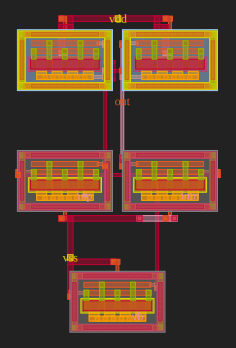

  nets routed : 5/5
  wire length : 126.16 um
  vias        : 21
  internal    : opens=0 shorts=0 drc=0


In [4]:
# ── 3. Preview + routing metrics ─────────────────────────────────────
from IPython.display import SVG, display

if r.get("svg_path") and os.path.isfile(r["svg_path"]):
    display(SVG(r["svg_path"]))

m = r.get("metrics", {})
if m:
    print(f"  nets routed : {m['routed_nets']}/{m['total_nets']}")
    print(f"  wire length : {m['wire_length']} um")
    print(f"  vias        : {m['via_count']}")
v = r.get("verification")
if v:
    print(f"  internal    : opens={v['opens']} shorts={v['shorts']} drc={v['drc']}")
